# Checking the Survival Probability

We check the spectral properties of the Perron-Frobenius operator $\hat{O}$ to wrap our head around the correct expression for the survival probabilty $S(n) = \vert| \hat{O}^n | \psi_0 \rangle \vert|^2$.

In [ ]:
import numpy as np
import pandas as pd
from scipy.linalg import expm 
import matplotlib.pyplot as plt 

##########################################
# graph size and chirality
##########################################

num_sites = 20
target_site = num_sites // 2
phi = 0
#phi = np.pi/(2*num_sites)
#phi = np.pi/(num_sites)
tau = 1.30

##########################################
# Laplacian matrix for a 1D line (L = D - A)
##########################################

# on-site energies set to 0
diag = 0 * np.eye(num_sites)
# first-neighbor hopping
upper_diag = np.exp(1j * phi) * np.eye(num_sites, k=1)
lower_diag = np.exp(-1j * phi) * np.eye(num_sites, k=-1)

# sum
L = diag + upper_diag + lower_diag
# add periodic boundary conditions (it becomes a ring...)
L[0,-1] = np.exp(-1j * phi)
L[-1,0] = np.exp(1j * phi)

# check the form of the matrix
print(rf"Laplacian matrix L for N = {num_sites}, phi = {phi}")
df_L = pd.DataFrame(L)
pd.set_option("display.precision", 3)
display(df_L)

##########################################
# unitary evolution
##########################################
U = expm(-1j * L * tau)

print(rf"Unitary step with tau = {tau}")
df_U = pd.DataFrame(U)
pd.set_option("display.precision", 3)
display(df_U)

##########################################
# projector P = 1 - D
##########################################
P = np.eye(num_sites)
P[target_site,target_site] = 0

print(rf"Projector on the 'parallel' subspace, where |target> = |{target_site}>")
df_P = pd.DataFrame(P)
pd.set_option("display.precision", 3)
display(df_P)

##########################################
# Perron-Frobenius operator
##########################################
O = P @ U

print(rf"Perron-Frobenius (or survival) operator O = P U")
df_O = pd.DataFrame(O)
pd.set_option("display.precision", 3)
display(df_O)

Laplacian matrix L for N = 10, phi = 0


,0,1,2,3,4,5,6,7,8,9
0,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j
1,1.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
2,0.0+0.0j,1.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
3,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
4,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
5,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
6,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j
7,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j
8,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,1.0+0.0j
9,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j


Unitary step with tau = 1.3


,0,1,2,3,4,5,6,7,8,9
0,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j
1,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j
2,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j
3,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j
4,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j
5,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j
6,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j
7,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j
8,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j
9,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j


Projector on the 'parallel' subspace, where |target> = |5>


,0,1,2,3,4,5,6,7,8,9
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Perron-Frobenius (or survival) operator O = P U


,0,1,2,3,4,5,6,7,8,9
0,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j
1,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j
2,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j
3,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j
4,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j
5,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
6,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j,0.000+0.236j
7,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j,-0.459+0.000j
8,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j,0.000-0.471j
9,0.000-0.471j,-0.459+0.000j,0.000+0.236j,0.079+0.000j,0.000-0.046j,0.079+0.000j,0.000+0.236j,-0.459+0.000j,0.000-0.471j,-0.097+0.000j


### Conflicting Formulas

Now we wish to check two formulas for the survival probability :

$$ S_1(n) = \sum_{j=0}^{N-1} |\mu_j|^{2n} \langle \psi_0 | \mu_j \rangle \langle \bar{\mu}_j | \psi_0 \rangle $$

$$ S_2(n) = \sum_{j,k=0}^{N-1} (\mu_j^* \mu_k)^n \langle \mu_j | \mu_k \rangle \langle \psi_0 | \bar{\mu}_j \rangle  \langle \bar{\mu}_k | \psi_0 \rangle $$

We first need some functions.

In [2]:
from scipy.linalg import eig

##########################################
# 1) compute all eigenvalues
##########################################

def calculate_eigenvalues(matrix):
    return np.linalg.eigvals(matrix)

##########################################
# 2) look for degeneracy or modulus one
##########################################

def check_degeneracy(eigenvalues, tolerance=1e-3):
    n = len(eigenvalues)
    for i in range(n):
        for j in range(i+1,n):
            if np.isclose(eigenvalues[i],eigenvalues[j], atol=tolerance):
                return True
    return False

def check_modulus_one(eigenvalues, tolerance=1e-3):
    n = len(eigenvalues)
    for i in range(n):
        if np.isclose(np.abs(eigenvalues[i]), 1.0, atol=tolerance):
            return True
    return False

##########################################
# 3) plot complex eigenvalues
##########################################
def plot_eigenvalues(eigenvalues):
    # "zorder" defines the order in which things are drawn 
    plt.figure(figsize=(6,6))
    plt.scatter(eigenvalues.real, eigenvalues.imag, color='g', marker='o', zorder=3)
    # axes 
    plt.axhline(0, color='black',linewidth=1, zorder=1)
    plt.axvline(0, color='black',linewidth=1, zorder=1)
    # unit circle (basically drawn with the help of polar coordinates)
    theta = np.linspace(0, 2*np.pi, 200)
    plt.plot(np.cos(theta), np.sin(theta), 'r--', alpha=0.5, zorder=2)
    # labels and proper plotting
    plt.xlabel('Re(z)')
    plt.ylabel('Im(z)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.axis('equal') # makes sure the ratio is 1:1
    plt.legend()
    plt.show()

##########################################
# 4) highest-modulus eigenvalue as a funct. of phi and tau
##########################################

def plot_O_leading_eigenvalue(num_sites, target_site, resolution = 250, tau_min = 0.02, tau_max = 3.00):
    phi_min = 0
    phi_max = +np.pi/num_sites
    tau_vals = np.linspace(tau_min, tau_max, resolution)
    phi_vals = np.linspace(phi_min, phi_max, resolution)

    Tau_grid, Phi_grid = np.meshgrid(tau_vals, phi_vals)
    max_mod_matrix = np.zeros_like(Tau_grid)

    # static projector
    Proj = np.eye(num_sites)
    Proj[target_site, target_site] = 0
    
    for i in range(Tau_grid.shape[0]):
        for j in range(Tau_grid.shape[1]):

            # pick values from the grid to make L (and H, and U...)
            current_tau = Tau_grid[i, j]
            current_phi = Phi_grid[i, j]
            # first-neigh.
            upper_diag_temp = np.exp(1j * current_phi) * np.eye(num_sites, k=1)
            lower_diag_temp = np.exp(-1j * current_phi) * np.eye(num_sites, k=-1)
            # periodic b.c.
            L_temp = upper_diag_temp + lower_diag_temp
            L_temp[0, -1] = np.exp(-1j * current_phi)
            L_temp[-1, 0] = np.exp(1j * current_phi)

            # O as a function of phi and tau!
            U_temp = expm(-1j * L_temp * current_tau)
            O_temp = Proj @ U_temp

            # find the greatest eigenvalue
            evals = np.linalg.eigvals(O_temp)
            max_mod_matrix[i, j] = np.max(np.abs(evals))

    plt.figure(figsize=(8,6))
    contour = plt.contour(Tau_grid, Phi_grid, max_mod_matrix, levels=100, cmap='viridis')
    #heatmap = plt.pcolormesh(Tau_grid, Phi_grid, max_mod_matrix, cmap='viridis', shading='auto')
    plt.colorbar(contour, label=f'max |\u03BC| of O')
    #plt.colorbar(heatmap, label=rf'max |\mu| of O')
    plt.xlabel('\u03C4')
    plt.ylabel('\u03C6')
    plt.show()
    
##########################################
# 5) biorthogonal decomposition
##########################################

def biorthogonal_decomposition(matrix):
    evals, left_evecs, right_evecs = eig(matrix, left=True, right=True)
    # normalization
    # i is the index of the eigenvector
    # : runs over its components
    for i in range(len(evals)): 
        overlap = np.vdot(left_evecs[:,i], right_evecs[:,i])
        if np.abs(overlap) > 1e-15: # don't wanna be dividing by 0...
            left_evecs[:, i] = left_evecs[:, i] / np.conj(overlap)

    return evals, left_evecs, right_evecs

##########################################
# 6) S_1(n) and S_2(n)
##########################################

import warnings

def plot_survival_probabilities(O_matrix, num_steps = 50, psi_0 = None, tolerance=1e-3, ylimit=0.6):

    N = O_matrix.shape[0]

    # if not otherwise specified, the initial state is localized at |0> 
    if psi_0 is None: 
        psi_0 = np.zeros(N, dtype=complex)
        psi_0[0] = 1.0

    mu, L_evecs, R_evecs = biorthogonal_decomposition(O_matrix)

    n_vals = np.arange(1, num_steps + 1) # given as an input to the function
    S1_vals = np.zeros(num_steps, dtype=float)
    S2_vals = np.zeros(num_steps, dtype=float)

    for idx, n in enumerate(n_vals):

        ############ S_1(n) ############  
         
        s1 = 0.0 + 0.0j
        for j in range(N):
            factor1 = np.abs(mu[j])**(2*n)
            factor2 = np.vdot(psi_0, R_evecs[:, j]) # <psi_0|mu_j>
            factor3 = np.vdot(L_evecs[:, j], psi_0) # <mu_bar_j|psi_0>
            s1 += factor1 * factor2 * factor3

        if np.abs(np.imag(s1)) > tolerance:
            warnings.warn(f"S_1(n={n}) has a non-negligible Im part = {np.imag(s1):.2e}")

        S1_vals[idx] = np.real(s1)

        ############ S_2(n) ############  

        s2 = 0.0 + 0.0j
        for j in range(N):
            for k in range(N):
                factor1 = (np.conj(mu[j])*mu[k])**n
                factor2 =  np.vdot(R_evecs[:, j], R_evecs[:, k]) # <mu_j|mu_k>                 
                factor3 =  np.vdot(psi_0, L_evecs[:, j]) # <psi_0|mu_bar_j> 
                factor4 =  np.vdot(L_evecs[:, k], psi_0) # <mu_bar_k|psi_0>
                s2 += factor1 * factor2 * factor3 * factor4
            if np.abs(np.imag(s2)) > tolerance:
                warnings.warn(f"S_2(n={n}) has a non-negligible Im part = {np.imag(s2):.2e}")
        
        S2_vals[idx] = np.real(s2)

    # plot for colorblind
    plt.figure(figsize=(9,6))
    plt.plot(n_vals, S1_vals, label='$S_1(n)$', color='#0072B2', linestyle='-', marker='o', alpha=0.8)
    plt.plot(n_vals, S2_vals, label='$S_2(n)$', color='#D55E00', linestyle='--', marker='x', alpha=0.8)
    plt.xlabel('step $n$')
    plt.ylabel('survival probability')
    plt.ylim(0,ylimit)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()
            



### Numerical Comparison

We now wanna compare $S_1$ and $S_2$ as a function of $n$, to see how different they are and if they converge to the same value as $n \to \infty$.

Parameters:
N = 10, phi = 0.0 % of pi/N, tau = 1.3
List of eigenvalues:
[-0.69617195-5.75708128e-01j  0.26833698-4.83084804e-01j
 -0.69617195+5.75708128e-01j -0.38846467+2.89459499e-16j
  0.26833698+4.83084804e-01j -0.50781616-8.61465467e-01j
  0.69423187-7.19751418e-01j -0.50781616+8.61465467e-01j
  0.69423187+7.19751418e-01j  0.        +0.00000000e+00j]
Is the spectrum of O degenerate? False
Any modulus one eigenvalue? True


/var/folders/w5/_xj_10752qq46lvtdj31knl40000gn/T/ipykernel_3775/4168107274.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


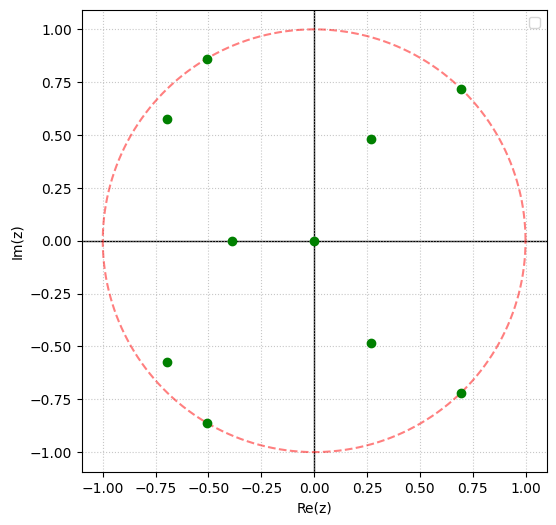

In [3]:
# 1) get the eigenvalues of the P.-F. operator

eigenvalues_O = calculate_eigenvalues(O)

print(f"Parameters:")
print(rf"N = {num_sites}, phi = {100.0*phi/(np.pi/num_sites)} % of pi/N, tau = {tau}")

print(f"List of eigenvalues:")
print(eigenvalues_O)

# 2) check degeneracy and modulus 1

has_deg = check_degeneracy(eigenvalues_O)
print(f"Is the spectrum of O degenerate? {has_deg}")

has_mod_one = check_modulus_one(eigenvalues_O)
print(f"Any modulus one eigenvalue? {has_mod_one}")

# 3) plot on the complex plane

plot_eigenvalues(eigenvalues_O)

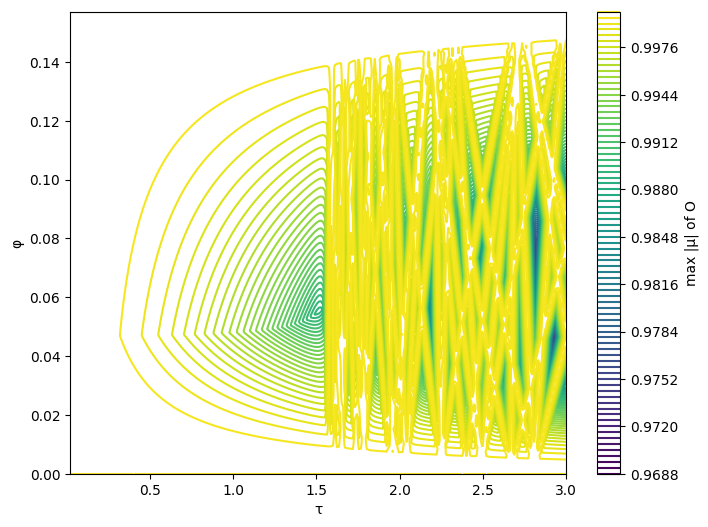

In [4]:
# 4) plot the eigenvalues of O as a function of phi and tau!
N = 20
plot_O_leading_eigenvalue(N, N//2)

In [5]:
# 5) carry out the biorthogonal decomposition
evals_B_decomp, L_Evecs, R_Evecs = biorthogonal_decomposition(O)
# check for biorthogonality
biorthogonality_check = L_Evecs.conj().T @ R_Evecs
print("L^dagger @ R (should be ~ Identity):\n")
df_BC = pd.DataFrame(biorthogonality_check)
#df_BC = pd.DataFrame(np.round(biorthogonality_check, 6))
pd.set_option("display.precision", 3)
display(df_BC)

L^dagger @ R (should be ~ Identity):



,0,1,2,3,4,5,6,7,8,9
0,1.000e+00+1.110e-16j,0.000e+00+2.220e-16j,2.776e-16-5.343e-16j,-2.220e-16-4.441e-16j,-2.776e-16+2.914e-16j,4.661e-17-1.105e-16j,7.672e-17-5.992e-16j,-1.491e-16+6.470e-17j,5.597e-17-4.336e-17j,-2.498e-16-2.220e-16j
1,5.551e-17-5.551e-17j,1.000e+00+5.551e-17j,1.665e-16-4.163e-16j,-2.776e-16-4.441e-16j,-9.437e-16-2.220e-16j,-4.647e-16-5.720e-16j,-2.549e-16-8.605e-16j,-1.045e-16-2.138e-16j,-8.761e-18-1.135e-16j,-1.110e-16-5.551e-16j
2,4.163e-16+3.123e-16j,1.943e-16+1.943e-16j,1.000e+00-1.110e-16j,-4.857e-17+4.996e-16j,4.163e-16-2.220e-16j,-2.411e-16+1.975e-16j,-4.878e-16+1.950e-16j,4.333e-16-5.833e-16j,-1.275e-16+7.060e-17j,5.551e-17+3.331e-16j
3,2.220e-16+1.110e-16j,-8.570e-16-3.331e-16j,3.331e-16-2.220e-16j,1.000e+00-9.861e-32j,-1.787e-16-8.882e-16j,7.552e-16+7.348e-16j,8.231e-16+5.009e-16j,-7.054e-16+3.452e-16j,-1.138e-16+2.807e-16j,2.220e-16-4.645e-16j
4,2.359e-16+2.776e-17j,-5.551e-16+6.106e-16j,2.220e-16+3.331e-16j,-2.220e-16-1.110e-16j,1.000e+00+1.110e-16j,1.100e-15-3.340e-16j,3.823e-16-2.535e-16j,4.189e-16+5.379e-16j,2.772e-16+1.288e-16j,-3.331e-16-1.110e-16j
5,-3.363e-17-3.968e-17j,-1.052e-16+7.542e-17j,-1.183e-16-2.083e-16j,2.230e-17+4.261e-17j,3.022e-16+9.486e-19j,1.000e+00+4.930e-32j,2.304e-17-1.133e-16j,-1.707e-16+1.451e-17j,-2.712e-16-2.545e-16j,2.857e-17+1.528e-17j
6,5.904e-17+3.610e-16j,-2.741e-16+2.630e-16j,-4.963e-17-4.504e-17j,-6.843e-17-2.066e-16j,-2.255e-16+2.124e-17j,1.116e-17+9.506e-17j,1.000e+00+2.465e-32j,-4.510e-16-3.476e-16j,-7.154e-17+9.555e-17j,-1.017e-16-3.070e-16j
7,-8.594e-17+1.278e-16j,-2.255e-16+3.333e-16j,4.962e-16+2.002e-16j,-3.283e-16-2.042e-16j,8.846e-18+1.022e-16j,-3.219e-16-2.653e-17j,-5.696e-16+3.922e-16j,1.000e+00+4.930e-32j,-2.810e-16+2.310e-16j,-2.831e-16-2.366e-16j
8,-3.967e-17+1.617e-16j,-1.407e-16+6.378e-17j,-2.505e-17-9.114e-17j,-2.755e-16-1.571e-16j,-4.511e-18+6.151e-17j,-2.123e-16+2.484e-16j,-1.465e-16-1.055e-16j,-1.887e-16-2.293e-16j,1.000e+00+4.930e-32j,-1.486e-16-1.461e-16j
9,0.000e+00+0.000e+00j,0.000e+00+0.000e+00j,0.000e+00+0.000e+00j,0.000e+00+0.000e+00j,0.000e+00+0.000e+00j,0.000e+00+0.000e+00j,0.000e+00+0.000e+00j,0.000e+00+0.000e+00j,0.000e+00+0.000e+00j,1.000e+00+0.000e+00j


/var/folders/w5/_xj_10752qq46lvtdj31knl40000gn/T/ipykernel_3775/4168107274.py:162: UserWarning: S_2(n=1) has a non-negligible Im part = -7.89e-02
  warnings.warn(f"S_2(n={n}) has a non-negligible Im part = {np.imag(s2):.2e}")
/var/folders/w5/_xj_10752qq46lvtdj31knl40000gn/T/ipykernel_3775/4168107274.py:162: UserWarning: S_2(n=1) has a non-negligible Im part = -6.94e-02
  warnings.warn(f"S_2(n={n}) has a non-negligible Im part = {np.imag(s2):.2e}")
/var/folders/w5/_xj_10752qq46lvtdj31knl40000gn/T/ipykernel_3775/4168107274.py:162: UserWarning: S_2(n=1) has a non-negligible Im part = 9.52e-03
  warnings.warn(f"S_2(n={n}) has a non-negligible Im part = {np.imag(s2):.2e}")
/var/folders/w5/_xj_10752qq46lvtdj31knl40000gn/T/ipykernel_3775/4168107274.py:162: UserWarning: S_2(n=2) has a non-negligible Im part = 4.25e-02
  warnings.warn(f"S_2(n={n}) has a non-negligible Im part = {np.imag(s2):.2e}")
/var/folders/w5/_xj_10752qq46lvtdj31knl40000gn/T/ipykernel_3775/4168107274.py:162: UserWarning: S_

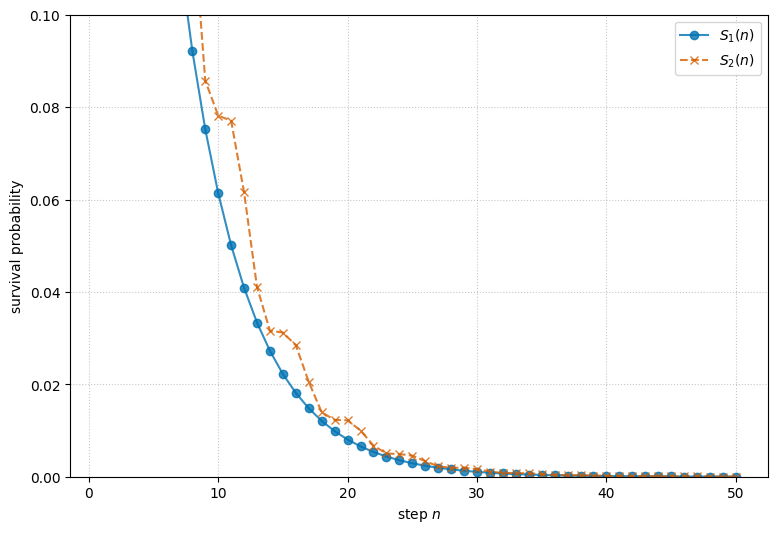

In [6]:
# 6) compare S_1 and S_2
plot_survival_probabilities(O, num_steps = 50, ylimit=0.1)